In [1]:
# Creates an FSI (fatal or serious injury) crash variable. The file summarizes FSI rates across jurisdiction groups 
# by total population, vun group, vun vs non-vun and visualizes these patterns with bar charts and heatmaps.
# vun = vulunerable people 
# It removes unclear jurisdiction categories ("Unknown" and "Other"), relabels "State" as "NYDOT"
# and Jurdiction with pedestrain vs cyclist

# Content:
# 1. Jurisdiction proportion of corresponding feature
# 2. Crash heatmap for corresponding feature
# 3. Chi square test of independence tests whether the distribution of the categorical outcome differs by group.
# 4. Cramér V as effect size measure for the chi square test. It indicates how strong the association is.
# 5. Logistic regression model to estimate odds ratios relative to the reference group.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import itertools

In [3]:
df = pd.read_csv("2012-24_Crash_Events_standardized_corridored_dataset.csv")

In [4]:
df["OWNING_JURISDICTION_TYPE_ID"].value_counts()

OWNING_JURISDICTION_TYPE_ID
1.0     80089
4.0     57226
2.0     28382
3.0      2477
11.0     2135
5.0       524
9.0       113
51.0       98
7.0         8
Name: count, dtype: int64

In [5]:
# mapping for jur_cde
mapj = {
    1: "State",
    2: "County",
    3: "Town",
    4: "City/Village",
    5: "Thruway",
    6: "Interstate",
    7: "Other",
    11: "State Parks",
    999: "Unknown"
}

In [6]:
df["OWNING_JURISDICTION"] = (
    df["OWNING_JURISDICTION_TYPE_ID"]
    .map(mapj)
    .fillna("Unknown")
)

In [7]:
df["CrashType"] = (
    df["CrashType"]
    .str.replace(r"^COLLISION WITH ", "COLL. W/", regex = True)
)

In [8]:
# Here, a crash is labeled FSI if it has:

# at least one fatality, or
# at least one serious injury
df['fatal_crash'] = (df['NumberOfFatalities'].fillna(0) > 0).astype(int)
df['serious_injury_crash'] = (df['NumberOfSeriousInjuries'].fillna(0) > 0).astype(int)
df['fsi_crash'] = ((df['fatal_crash'] == 1) | (df['serious_injury_crash'] == 1)).astype(int) 

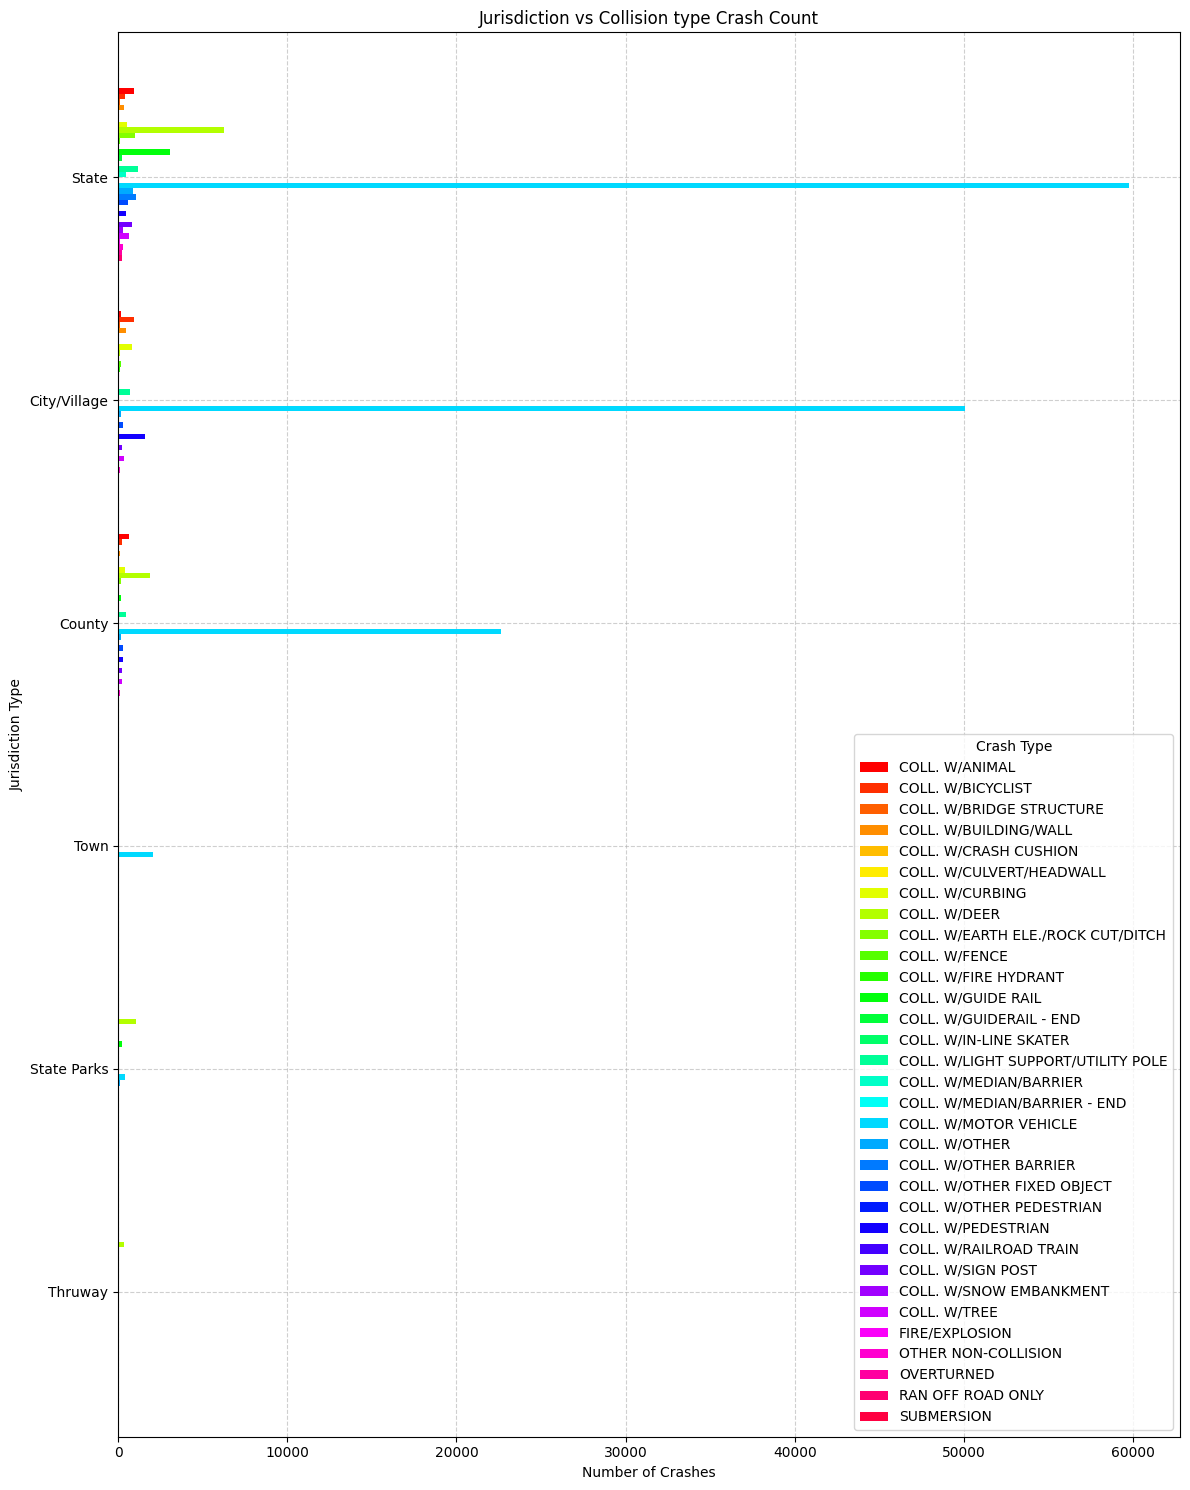

In [9]:
df_selected = df[
    (df["OWNING_JURISDICTION"] != "Unknown") &
    (df["OWNING_JURISDICTION"] != "Other") &
    (df["CrashType"] != "UNKNOWN") &
    (df["CrashType"] != "INVALID CODE") &
    (df["CrashType"] != "NOT ENTERED")
].copy()

stat = df_selected.groupby(["OWNING_JURISDICTION", "CrashType"]).size().reset_index(name = "Count")

stat_wide = stat.pivot(index = "OWNING_JURISDICTION", columns = "CrashType", values = "Count").fillna(0)

stat_wide["Total"] = stat_wide.sum(axis = 1)
stat_wide = stat_wide.sort_values("Total", ascending = False)
stat_wide = stat_wide.drop(columns = "Total")

n = len(stat_wide.columns)
colors = plt.cm.hsv(np.linspace(0, 1, n, endpoint = False))
colors = colors[:n]

ax = stat_wide.plot(kind = "barh",width = 0.8, figsize = (12, 15), color = colors)

plt.xlabel("Number of Crashes")
plt.ylabel("Jurisdiction Type")
plt.title("Jurisdiction vs Collision type Crash Count")
plt.legend(
    title = "Crash Type",
    loc = "lower right"
)

ax.grid(True, linestyle = "--", alpha = 0.6)
ax.set_axisbelow(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
crosstb = pd.crosstab(
    df_selected["OWNING_JURISDICTION"],
    df_selected["CrashType"]
)

In [11]:
crosstb_jp = pd.crosstab(
    df_selected["OWNING_JURISDICTION"],
    df_selected["CrashType"],
    normalize = "columns"
)

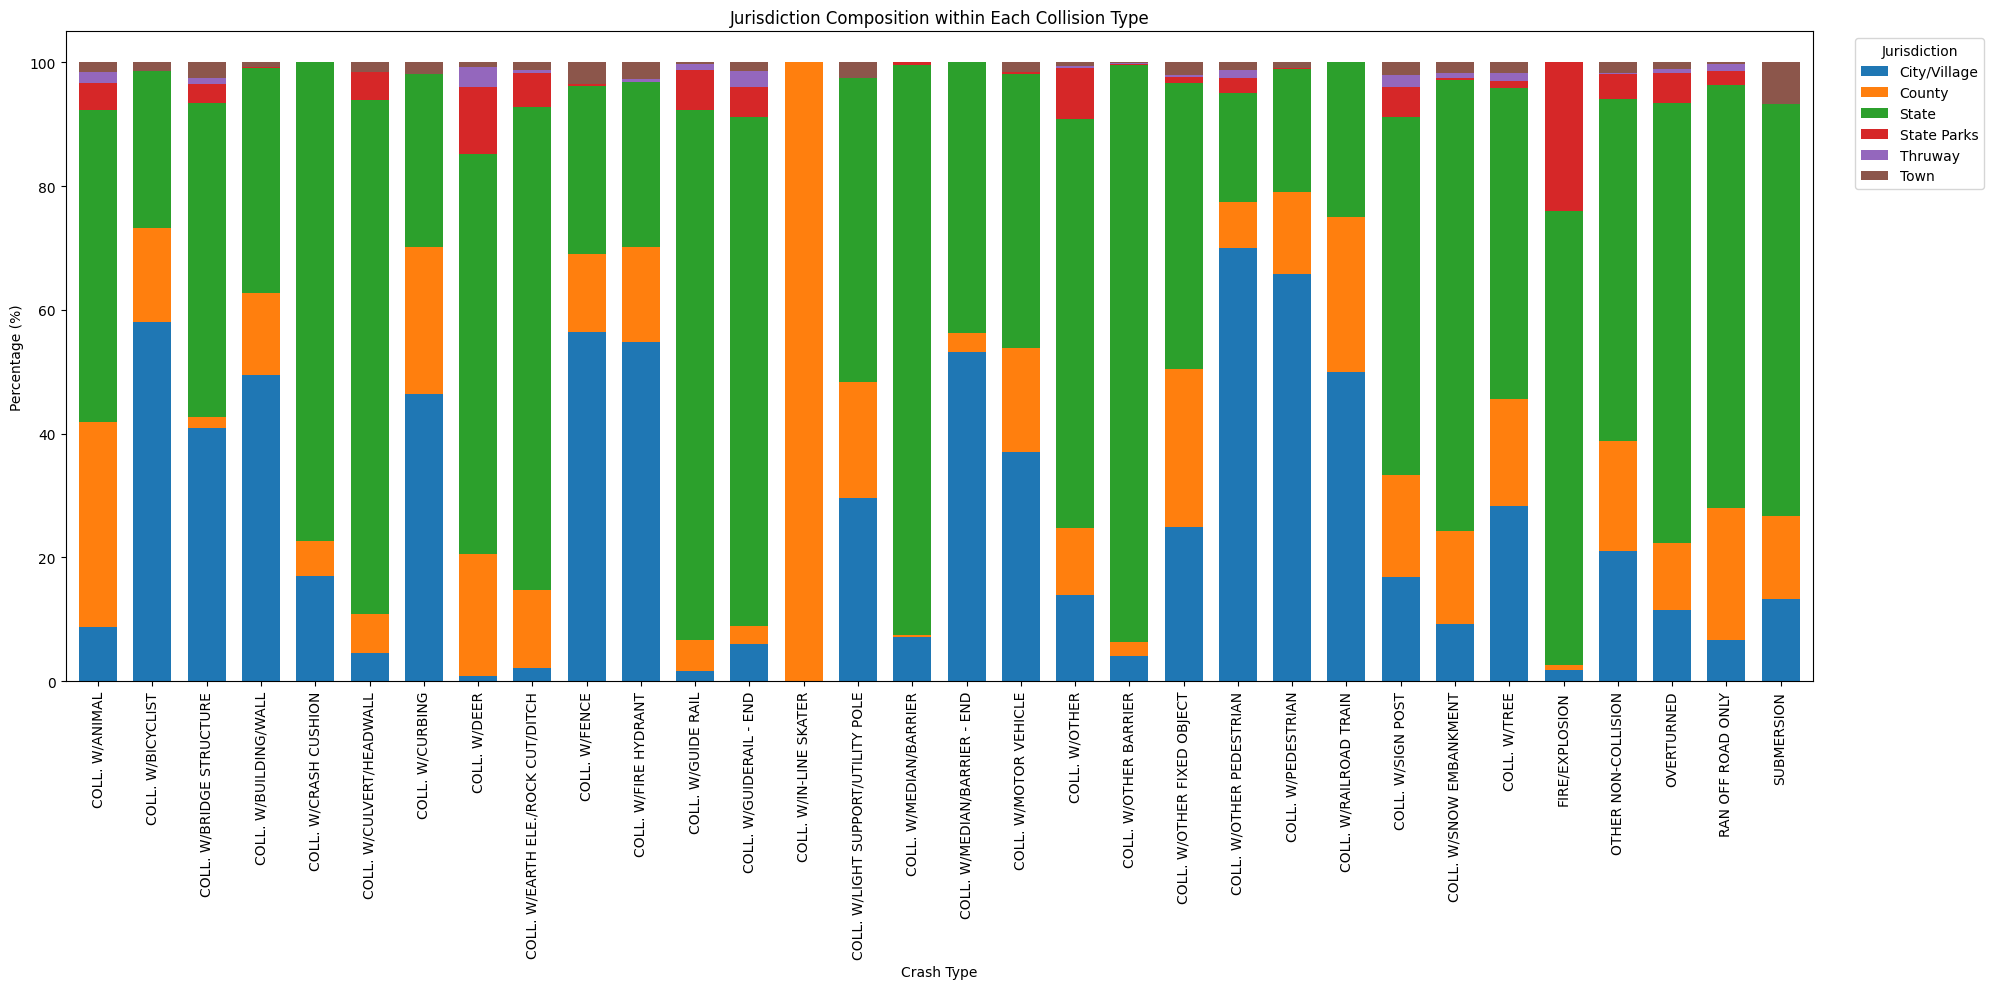

In [12]:
# crosstb_cp.sort_values("COLLISION WITH PEDESTRIAN", ascending = False)

df_plot = (crosstb_jp.T * 100)

ax = df_plot.plot(
    kind = "bar",
    stacked = True,
    figsize = (20, 10),
    width = 0.7
)

plt.xlabel("Crash Type")
plt.ylabel("Percentage (%)")
plt.title("Jurisdiction Composition within Each Collision Type")
plt.legend(title = "Jurisdiction", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

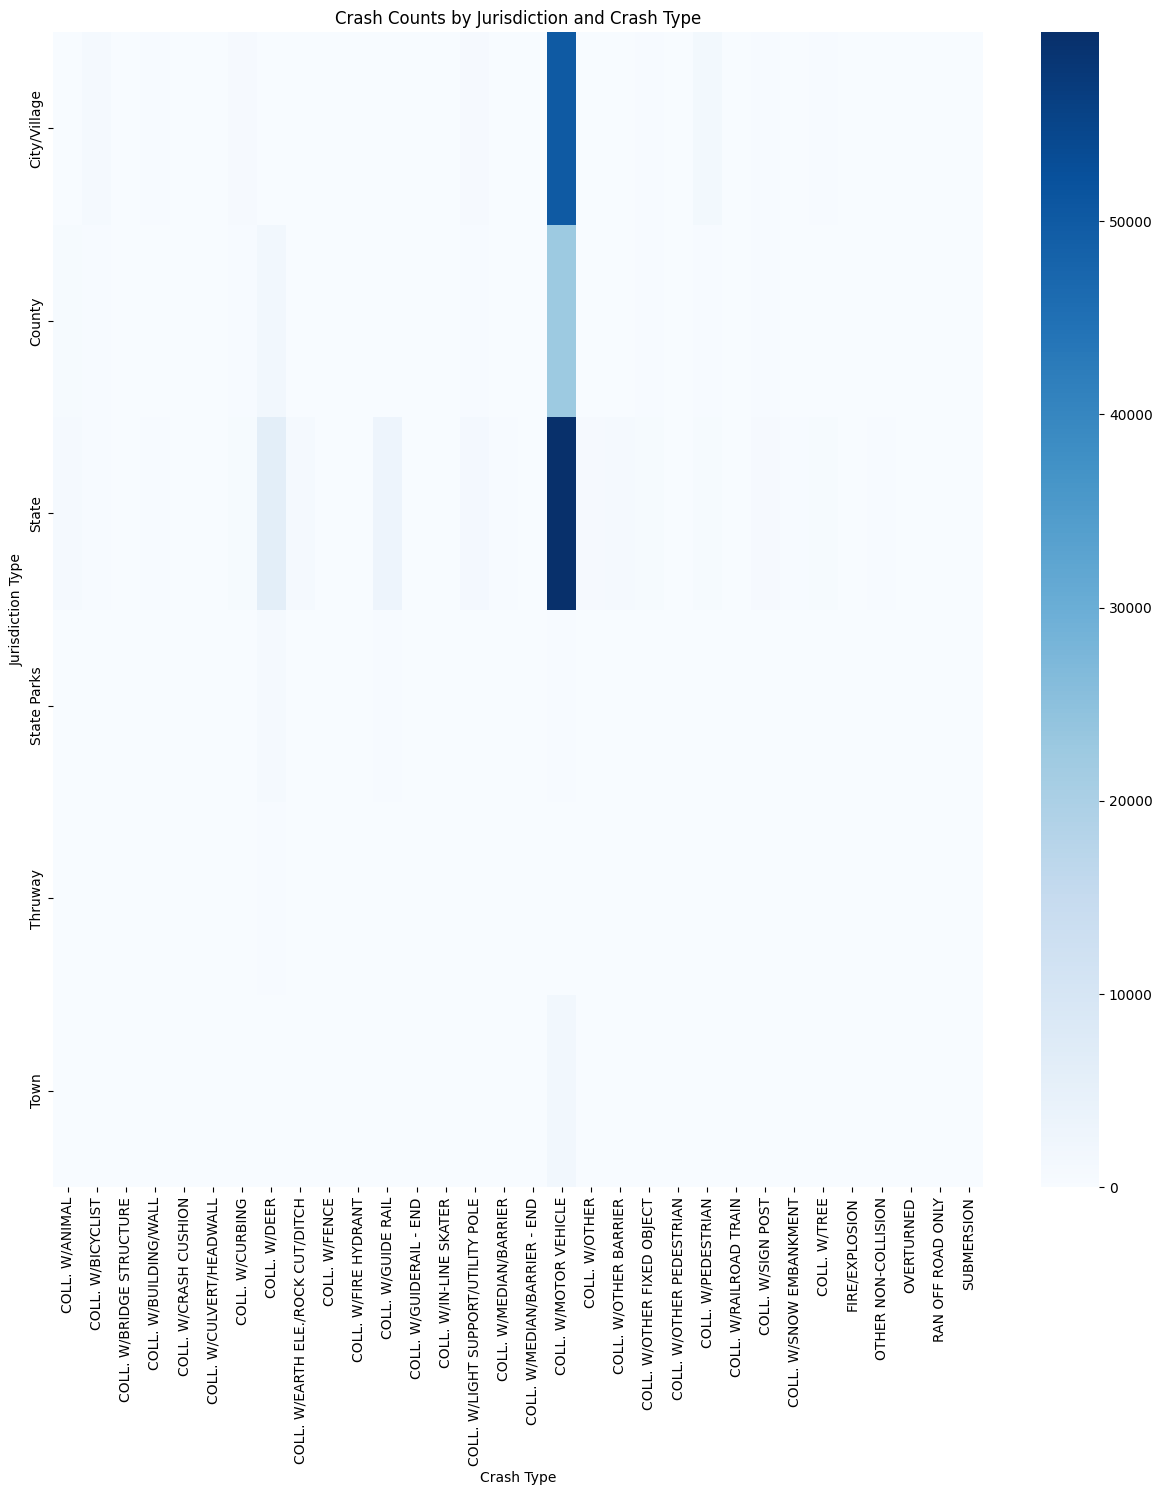

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (15, 15))
sns.heatmap(crosstb, annot = False, fmt = "d", cmap = "Blues")
plt.title("Crash Counts by Jurisdiction and Crash Type")
plt.xlabel("Crash Type")
plt.ylabel("Jurisdiction Type")
plt.show()

In [14]:
# Test of Independence
# H0 = OWNING_JURISDICTION and CrashType independent
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(crosstb)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# The chi-square test of independence showed a significant association between OWNING_JURISDICTION and CrashType, χ2(155) = 27237.95,
# p < 0.001. We therefore reject the null hypothesis of independence and conclude that crash type distribution  differs significantly
# across jurisdiction types.

Chi-square: 27237.948060735063
p-value: 0.0
Degrees of freedom: 155


In [15]:
n = crosstb.to_numpy().sum()
r, c = crosstb.shape

cv = np.sqrt(chi2 / (n * min(r - 1, c - 1)))
print("Cramér's V:", cv)

# Cramér’s V indicates a small effect size, suggesting that the association between jurisdiction 
# type and crash type is statistically significant but not very strong in practical terms.

Cramér's V: 0.17886294236164277


In [16]:
stat_fsi = (
    df_selected.groupby(["OWNING_JURISDICTION", "CrashType"])
    .agg(
        TotalCrashes = ("CrashType", "count"),
        TotalFSI = ("fsi_crash", "sum")
    )
    .reset_index()
)

stat_fsi["FSIRate"] = stat_fsi["TotalFSI"] / stat_fsi["TotalCrashes"]
fsi_rate = stat_fsi.pivot(index = "OWNING_JURISDICTION", columns = "CrashType", values = "FSIRate").fillna(0)

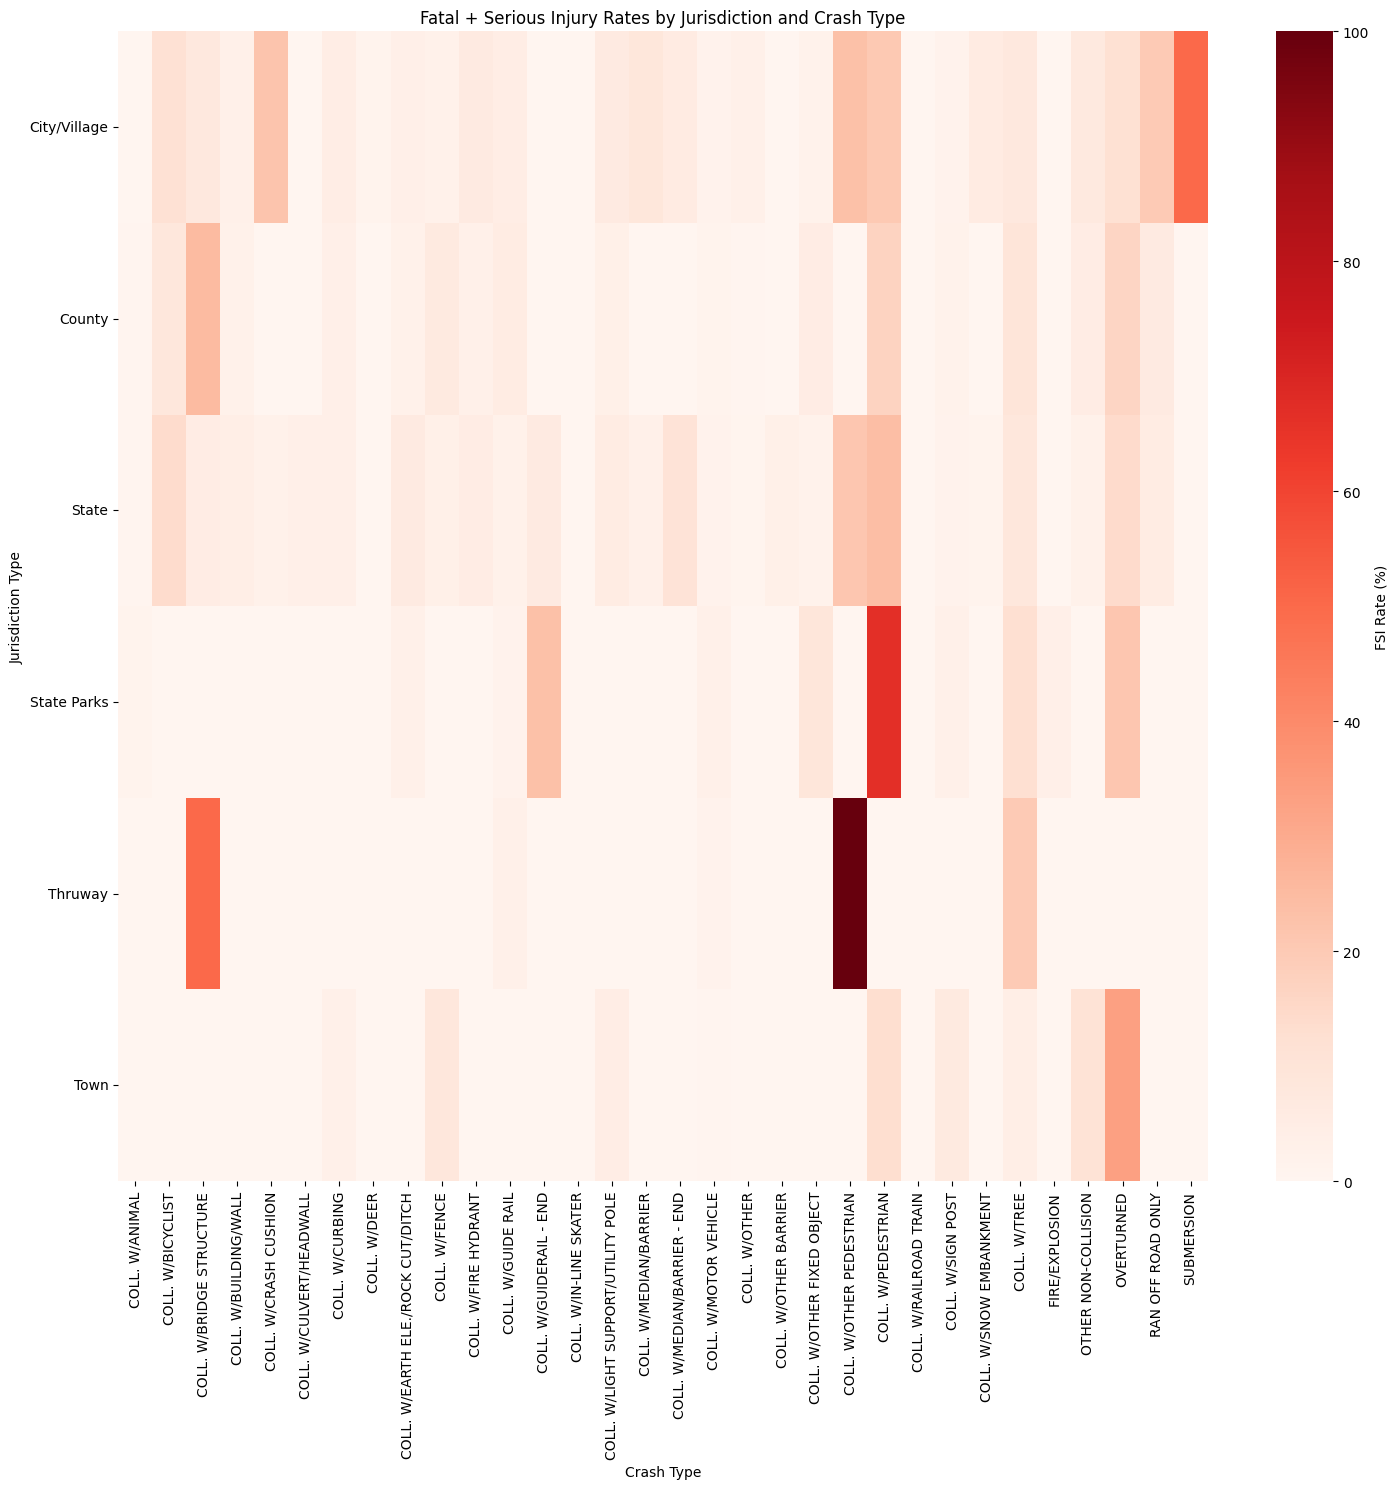

In [17]:
plt.figure(figsize = (15, 15))
sns.heatmap(fsi_rate * 100, annot =  False, fmt = "", cmap = "Reds", cbar_kws = {"label": "FSI Rate (%)"})
plt.title("Fatal + Serious Injury Rates by Jurisdiction and Crash Type")
plt.xlabel("Crash Type")
plt.ylabel("Jurisdiction Type")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [18]:
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

In [19]:
stat_fsi_wide = stat_fsi.pivot(index = "OWNING_JURISDICTION", columns = "CrashType", values = ["TotalCrashes", "TotalFSI"]).fillna(0)
stat_fsi_wide.columns = [
    f"{x}_{y}" 
    for x, y in stat_fsi_wide.columns
]
stat_fsi_wide = stat_fsi_wide.reset_index()
stat_fsi_wide

,OWNING_JURISDICTION,TotalCrashes_COLL. W/ANIMAL,TotalCrashes_COLL. W/BICYCLIST,TotalCrashes_COLL. W/BRIDGE STRUCTURE,TotalCrashes_COLL. W/BUILDING/WALL,TotalCrashes_COLL. W/CRASH CUSHION,TotalCrashes_COLL. W/CULVERT/HEADWALL,TotalCrashes_COLL. W/CURBING,TotalCrashes_COLL. W/DEER,TotalCrashes_COLL. W/EARTH ELE./ROCK CUT/DITCH,...,TotalFSI_COLL. W/PEDESTRIAN,TotalFSI_COLL. W/RAILROAD TRAIN,TotalFSI_COLL. W/SIGN POST,TotalFSI_COLL. W/SNOW EMBANKMENT,TotalFSI_COLL. W/TREE,TotalFSI_FIRE/EXPLOSION,TotalFSI_OTHER NON-COLLISION,TotalFSI_OVERTURNED,TotalFSI_RAN OFF ROAD ONLY,TotalFSI_SUBMERSION
0,City/Village,163.0,953.0,94.0,436.0,9.0,3.0,829.0,82.0,27.0,...,321.0,0.0,4.0,2.0,27.0,0.0,8.0,4.0,4.0,1.0
1,County,615.0,251.0,4.0,117.0,3.0,4.0,425.0,1895.0,161.0,...,54.0,0.0,5.0,0.0,21.0,0.0,5.0,5.0,4.0,0.0
2,State,939.0,416.0,117.0,321.0,41.0,54.0,500.0,6239.0,994.0,...,113.0,0.0,14.0,4.0,53.0,0.0,8.0,29.0,12.0,0.0
3,State Parks,79.0,0.0,7.0,1.0,0.0,3.0,0.0,1034.0,71.0,...,2.0,0.0,2.0,0.0,2.0,1.0,0.0,3.0,0.0,0.0
4,Thruway,33.0,0.0,2.0,0.0,0.0,0.0,2.0,324.0,7.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
5,Town,30.0,23.0,6.0,7.0,0.0,1.0,33.0,67.0,15.0,...,3.0,0.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0


In [20]:
# H0 = All FSI proportion are equal for different collison type

summary = df_selected.groupby("CrashType").agg( TotalCrashes = ("CrashType", "size"), TotalFSI = ("fsi_crash", "sum")).reset_index()
summary["NonFSI"] = summary["TotalCrashes"] - summary["TotalFSI"]
summary["FSIRate"] = summary["TotalFSI"] / summary["TotalCrashes"]
summary = summary[summary["TotalCrashes"] >= 20].copy()


crosstab = summary[["TotalFSI", "NonFSI"]].to_numpy().T
chi2, p, dof, expected = chi2_contingency(crosstab)


print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

# Chis-quare test showed that the overall proportions of Crash type FSI crashes were not equal, 
# where X2(28) = 5846.27, p < 0.001. Therefore, the null hypothesis is rejected.

Chi-square statistic: 5846.268588976674
p-value: 0.0
degrees of freedom: 28


In [21]:
# H0 = All FSI proportion are equal for different collison type

results = []
for j, sub in df_selected.groupby("OWNING_JURISDICTION"):
    summary = sub.groupby("CrashType").agg( TotalCrashes = ("CrashType", "size"), TotalFSI = ("fsi_crash", "sum")).reset_index()
    summary["NonFSI"] = summary["TotalCrashes"] - summary["TotalFSI"]
    summary["FSIRate"] = summary["TotalFSI"] / summary["TotalCrashes"]
    summary = summary[summary["TotalCrashes"] >= 20].copy()
    if summary.shape[0] < 2:
        results.append({"Test": "Not applicable", "Jurisdiction": j, "p_value": np.nan})
    
    crosstab = summary[["TotalFSI", "NonFSI"]].to_numpy().T
    chi2, p, dof, expected = chi2_contingency(crosstab)

    results.append({"Test": "Chi-square", "Jurisdiction" : j, "p_value": p })

df_testresult = pd.DataFrame(results)
mask = df_testresult["p_value"].notna()
df_testresult.loc[mask, "p_adj_bonf"] = multipletests(df_testresult.loc[mask, "p_value"], method = "bonferroni")[1]
df_testresult.loc[mask, "significance (95% interval)"] = df_testresult.loc[mask, "p_adj_bonf"] < 0.05

print(df_testresult)

# After comparing FSI number between each crash type within each jurisdiction and applying Bonferroni correction, significant differences 
# were found in City/Village, County, State, State parks and Town, were not found in Thruway.

         Test  Jurisdiction        p_value     p_adj_bonf  \
0  Chi-square  City/Village   0.000000e+00   0.000000e+00   
1  Chi-square        County  1.258974e-132  7.553843e-132   
2  Chi-square         State   0.000000e+00   0.000000e+00   
3  Chi-square   State Parks   2.384422e-04   1.430653e-03   
4  Chi-square       Thruway   5.462701e-02   3.277621e-01   
5  Chi-square          Town   2.579154e-10   1.547493e-09   

  significance (95% interval)  
0                        True  
1                        True  
2                        True  
3                        True  
4                       False  
5                        True  


In [22]:
model = smf.logit('fsi_crash ~ C(CrashType,Treatment(reference="COLL. W/MOTOR VEHICLE")) + C(OWNING_JURISDICTION)', data = df_selected).fit_regularized(alpha = 1, trim_mode ='size')

print(model.summary())

oddratio_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "p_value": model.pvalues
})
print(oddratio_table)

# Although logistic regression model converged successfully. 2 parameters did not fully pass post-estimation QC checks, 
# likely due to sparse categories.

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.09685514279194388
            Iterations: 625
            Function evaluations: 625
            Gradient evaluations: 625


C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 2 out of 37 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)


                           Logit Regression Results                           
Dep. Variable:              fsi_crash   No. Observations:               170280
Model:                          Logit   Df Residuals:                   170250
Method:                           MLE   Df Model:                           29
Date:                Sat, 02 May 2026   Pseudo R-squ.:                 0.08039
Time:                        23:19:22   Log-Likelihood:                -16457.
converged:                       True   LL-Null:                       -17896.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                             

# Vun vs Non Vun

In [23]:
vun_types = ["COLL. W/BICYCLIST", "COLL. W/PEDESTRIAN","COLL. W/OTHER PEDESTRIAN"]

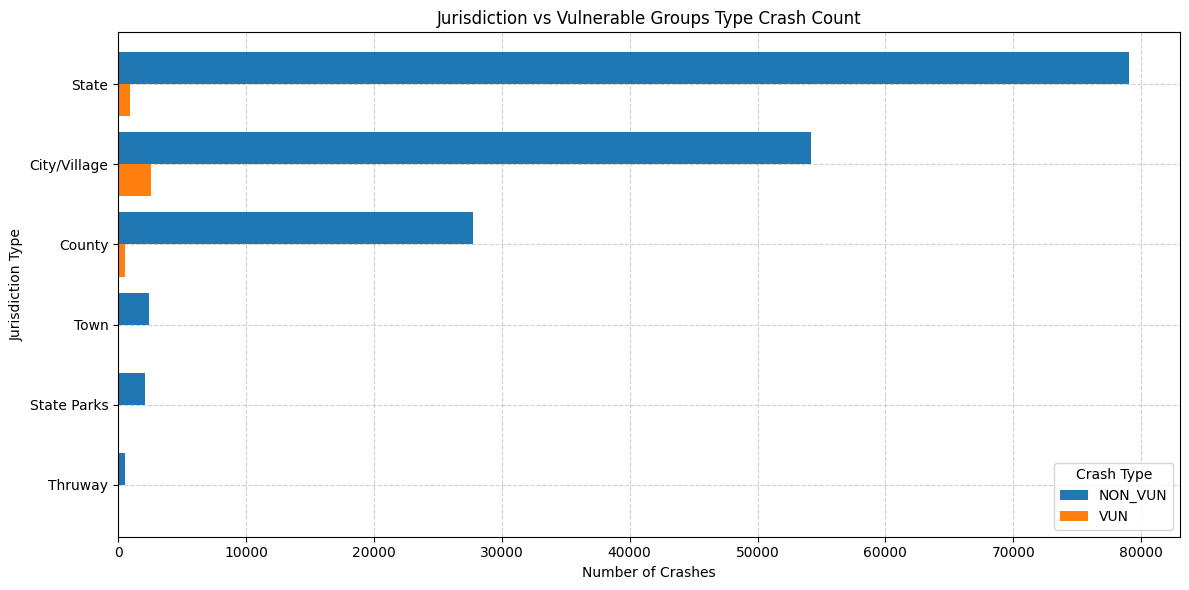

In [24]:
df_selected["VUN_group"] = np.where(df_selected["CrashType"].isin(vun_types), "VUN", "NON_VUN")

stat = (
    df_selected.groupby(["OWNING_JURISDICTION", "VUN_group"])
    .size()
    .reset_index(name = "Count")
)

stat_wide = stat.pivot(index = "OWNING_JURISDICTION", columns = "VUN_group", values = "Count").fillna(0)

stat_wide["Total"] = stat_wide.sum(axis = 1)
stat_wide = stat_wide.sort_values("Total", ascending = False)
stat_wide = stat_wide.drop(columns = "Total")


ax = stat_wide.plot(kind = "barh",width = 0.8, figsize = (12, 6))

plt.xlabel("Number of Crashes")
plt.ylabel("Jurisdiction Type")
plt.title("Jurisdiction vs Vulnerable Groups Type Crash Count")
plt.legend(
    title = "Crash Type",
    loc = "lower right"
)

ax.grid(True, linestyle = "--", alpha = 0.6)
ax.set_axisbelow(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
crosstb = pd.crosstab(
    df_selected["OWNING_JURISDICTION"],
    df_selected["VUN_group"]
)

In [26]:
crosstb_jp = pd.crosstab(
    df_selected["OWNING_JURISDICTION"],
    df_selected["VUN_group"],
    normalize = "columns"
)

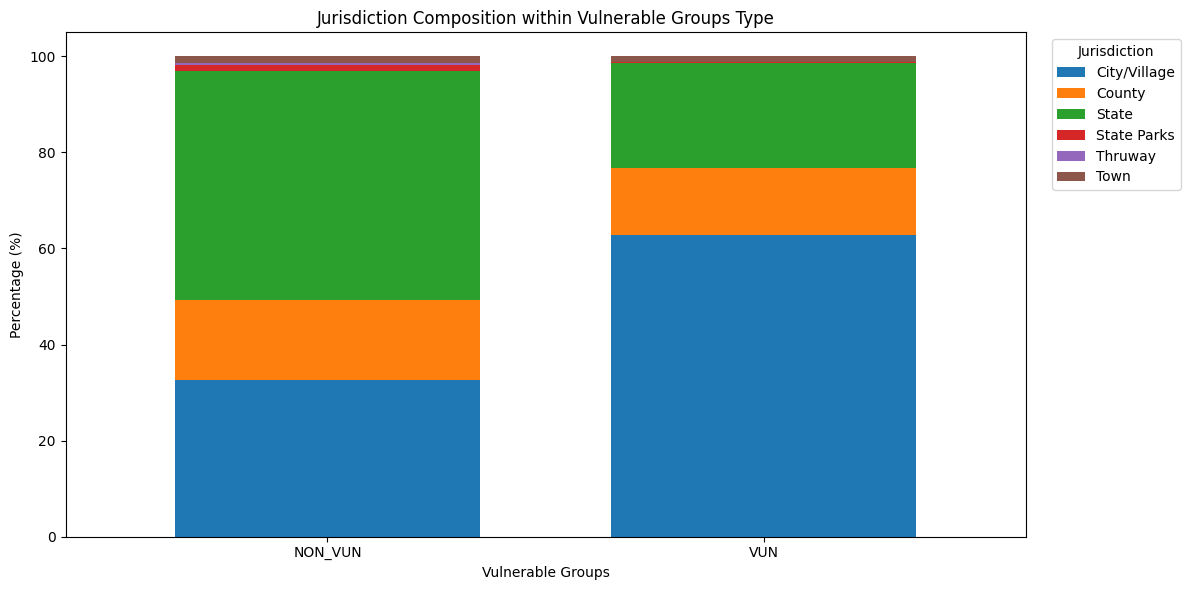

In [27]:

df_plot = (crosstb_jp.T * 100)

ax = df_plot.plot(
    kind = "bar",
    stacked = True,
    figsize = (12, 6),
    width = 0.7
)

plt.xlabel("Vulnerable Groups")
plt.ylabel("Percentage (%)")
plt.title("Jurisdiction Composition within Vulnerable Groups Type")
plt.legend(title = "Jurisdiction", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

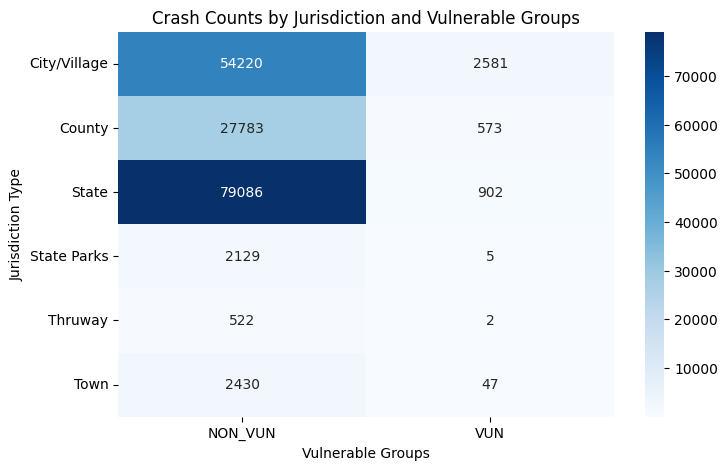

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))
sns.heatmap(crosstb, annot = True, fmt = "d", cmap = "Blues")
plt.title("Crash Counts by Jurisdiction and Vulnerable Groups")
plt.xlabel("Vulnerable Groups")
plt.ylabel("Jurisdiction Type")
plt.show()

In [29]:
# Test of Independence
# H0 = OWNING_JURISDICTION and Vulnerable Group types independent
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(crosstb)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# The chi-square test of independence showed a significant association between OWNING_JURISDICTION and CrashType, X2(5) = 1729.57,
# p < 0.001. We therefore reject the null hypothesis

Chi-square: 1729.572511273825
p-value: 0.0
Degrees of freedom: 5


In [30]:
n = crosstb.to_numpy().sum()
r, c = crosstb.shape

cv = np.sqrt(chi2 / (n * min(r - 1, c - 1)))
print("Cramér's V:", cv)

# Cramér’s V indicates a small effect size, suggesting that the association is statistically significant but not very strong in practical terms.

Cramér's V: 0.10078306603445837


In [31]:
stat_fsi = (
    df_selected.groupby(["OWNING_JURISDICTION", "VUN_group"])
    .agg(
        TotalCrashes = ("CrashType", "count"),
        TotalFSI = ("fsi_crash", "sum")
    )
    .reset_index()
)

stat_fsi["FSIRate"] = stat_fsi["TotalFSI"] / stat_fsi["TotalCrashes"]
fsi_rate = stat_fsi.pivot(index = "OWNING_JURISDICTION", columns = "VUN_group", values = "FSIRate").fillna(0)

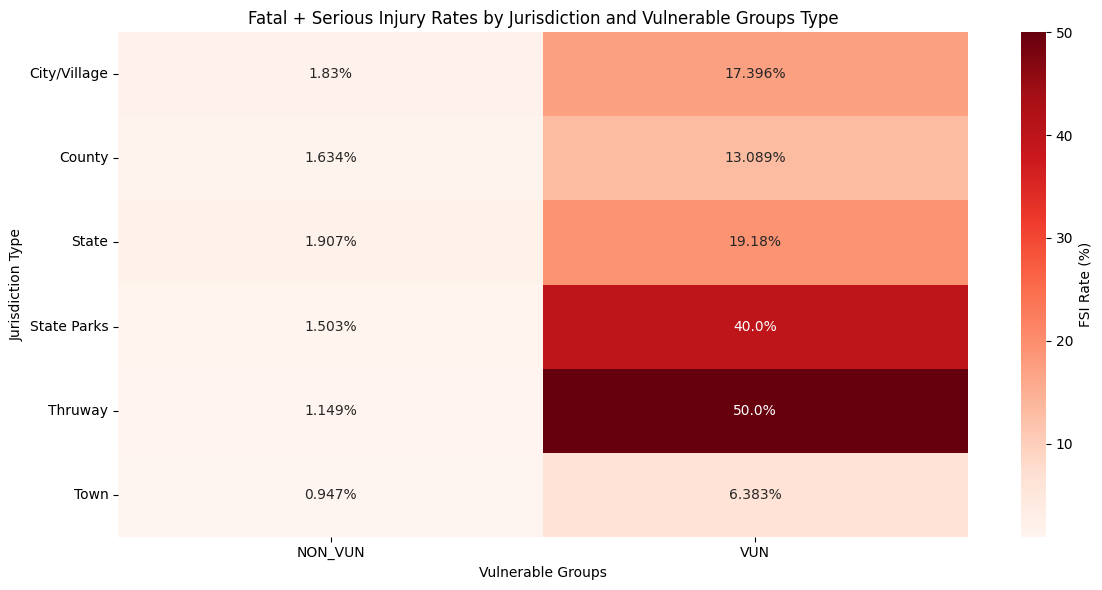

In [32]:
plt.figure(figsize = (12, 6))
labels_p = (fsi_rate * 100).round(3).astype(str) + "%"
sns.heatmap(fsi_rate * 100, annot =  labels_p, fmt = "", cmap = "Reds", cbar_kws = {"label": "FSI Rate (%)"})
plt.title("Fatal + Serious Injury Rates by Jurisdiction and Vulnerable Groups Type")
plt.xlabel("Vulnerable Groups")
plt.ylabel("Jurisdiction Type")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

df_test = df_selected.copy()
summary = df_test.groupby("VUN_group")["fsi_crash"].agg(TotalCrashes = "count", TotalFSI = "sum").reset_index()

summary["non_fsi"] = summary["TotalCrashes"] - summary["TotalFSI"]
summary["fsi_rate"] = summary["TotalFSI"] / summary["TotalCrashes"]

print(summary)


  VUN_group  TotalCrashes  TotalFSI  non_fsi  fsi_rate
0   NON_VUN        166170      3015   163155  0.018144
1       VUN          4110       703     3407  0.171046


In [34]:
# H0 = non vulnerable FSI = vunlerable FSI
vun_fsi = summary.loc[summary["VUN_group"] == "VUN", "TotalFSI"].iloc[0]
vun_total = summary.loc[summary["VUN_group"] == "VUN", "TotalCrashes"].iloc[0]

nonvun_fsi = summary.loc[summary["VUN_group"] == "NON_VUN", "TotalFSI"].iloc[0]
nonvun_total = summary.loc[summary["VUN_group"] == "NON_VUN", "TotalCrashes"].iloc[0]

count = [vun_fsi, nonvun_fsi]
numobs = [vun_total, nonvun_total]

z_stat, p_val = proportions_ztest(count, numobs)
results.append({"Test": "one sample proportion z-test" , "Jurisdiction": z_stat, "p_value": p_val})

print("z-statistic =", z_stat)
print("p-value =", p_val)

# two proportion z test showed that the overall proportions of nonvunlerable and vunlerable crashes were not equal, 
# where z = 66.25,p < 0.001. Therefore, the null hypothesis is rejected.

z-statistic = 66.25978223848405
p-value = 0.0


In [35]:
# H0 = non vulnerable FSI = vunlerable FSI by juridiction
results = []
for j, sub in df_selected.groupby("OWNING_JURISDICTION"):
    df_test = sub.copy()
    df_test["VUN_group"] = np.where(df_test["CrashType"].isin(vun_types), "VUN", "NON_VUN")
    summary = df_test.groupby("VUN_group")["fsi_crash"].agg(TotalCrashes = "count", TotalFSI = "sum").reset_index()
    summary["non_fsi"] = summary["TotalCrashes"] - summary["TotalFSI"]
    summary["fsi_rate"] = summary["TotalFSI"] / summary["TotalCrashes"]

    vun_fsi = summary.loc[summary["VUN_group"] == "VUN", "TotalFSI"].iloc[0]
    vun_total = summary.loc[summary["VUN_group"] == "VUN", "TotalCrashes"].iloc[0]

    nonvun_fsi = summary.loc[summary["VUN_group"] == "NON_VUN", "TotalFSI"].iloc[0]
    nonvun_total = summary.loc[summary["VUN_group"] == "NON_VUN", "TotalCrashes"].iloc[0]

    count = [vun_fsi, nonvun_fsi]
    numobs = [vun_total, nonvun_total]

    stat, p = proportions_ztest(count, numobs)
    results.append({"Test": "Two-proportion z-test", "Jurisdiction": j, "p_value": p})


df_testresult = pd.DataFrame(results)
mask = df_testresult["p_value"].notna()
df_testresult.loc[mask, "p_adj_bonf"] = multipletests(df_testresult.loc[mask, "p_value"], method = "bonferroni")[1]
df_testresult.loc[mask, "significance (95% interval)"] = df_testresult.loc[mask, "p_adj_bonf"] < 0.05

print(df_testresult)

# A two-proportion z test was conducted within each jurisdiction to compare the FSI proportions between vulnerable road user crashes and 
# non-vulnerable road user crashes. After Bonferroni correction for multiple comparisons, all jurisdictions remained statistically
# significant (padj < 0.05). Therefore, the null hypothesis was rejected.

                    Test  Jurisdiction        p_value     p_adj_bonf  \
0  Two-proportion z-test  City/Village   0.000000e+00   0.000000e+00   
1  Two-proportion z-test        County   1.667515e-89   1.000509e-88   
2  Two-proportion z-test         State  3.280175e-283  1.968105e-282   
3  Two-proportion z-test   State Parks   6.571023e-12   3.942614e-11   
4  Two-proportion z-test       Thruway   1.900597e-09   1.140358e-08   
5  Two-proportion z-test          Town   2.920908e-04   1.752545e-03   

  significance (95% interval)  
0                        True  
1                        True  
2                        True  
3                        True  
4                        True  
5                        True  


In [36]:
df_logit = df_selected.copy()
model = smf.logit('fsi_crash ~ C(VUN_group) + C(OWNING_JURISDICTION)', data = df_logit).fit(maxiter = 500)

print(model.summary())

oddratio_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "p_value": model.pvalues
})

print(oddratio_table)

# After controlling for owning jurisdiction, vulnerable crashes have substantially higher odds of being FSI crashes than
# non-vulnerable crashes. The estimated odds are about 11.23 times as high, and this effect is highly statistically significant.

Optimization terminated successfully.
         Current function value: 0.099480
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              fsi_crash   No. Observations:               170280
Model:                          Logit   Df Residuals:                   170273
Method:                           MLE   Df Model:                            6
Date:                Sat, 02 May 2026   Pseudo R-squ.:                 0.05343
Time:                        23:19:24   Log-Likelihood:                -16940.
converged:                       True   LL-Null:                       -17896.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -3.9808      

# Vun

In [69]:
df = pd.read_csv("pedestrian_cyclist_collisions_all.csv")

In [70]:
df.shape

(6997, 67)

In [71]:
df["OWNING_JURISDICTION_TYPE_ID"].value_counts()

OWNING_JURISDICTION_TYPE_ID
4.0     4053
1.0     1128
2.0      898
3.0      305
9.0       14
51.0       6
11.0       6
5.0        2
7.0        1
53.0       1
6.0        1
Name: count, dtype: int64

In [72]:
mapj = {
    1: "State",
    2: "County",
    3: "Town",
    4: "City/Village",
    5: "Thruway",
    6: "Other",
    7: "Other",
    11: "State Parks",
    999: "Unknown"
}

In [73]:
df["OWNING_JURISDICTION"] = (
    df["OWNING_JURISDICTION_TYPE_ID"]
    .map(mapj)
    .fillna("Unknown")
)

In [74]:
target_types = ["COLLISION WITH PEDESTRIAN", "COLLISION WITH BICYCLIST"]

In [75]:
df['fatal_crash'] = (df['NumberOfFatalities'].fillna(0) > 0).astype(int)
df['serious_injury_crash'] = (df['NumberOfSeriousInjuries'].fillna(0) > 0).astype(int)
df['fsi_crash'] = ((df['fatal_crash'] == 1) | (df['serious_injury_crash'] == 1)).astype(int)

In [76]:
df_selected = df[
    (df["OWNING_JURISDICTION"] != "Unknown") &
    (df["OWNING_JURISDICTION"] != "Other") & 
    (df["CrashType"].isin(target_types))
].copy()

In [77]:
from scipy.stats import chi2_contingency
clean2 = df_selected[["OWNING_JURISDICTION", "fsi_crash"]].dropna()
ct = pd.crosstab(clean2["OWNING_JURISDICTION"], clean2["fsi_crash"])
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 22.54446437710882
p-value: 0.0004124155352586168
Degrees of freedom: 5


In [78]:
n = ct.to_numpy().sum()
r, c = ct.shape

cv = np.sqrt(chi2 / (n * min(r - 1, c - 1)))
print("Cramér's V:", cv)

# Cramér’s V indicates a small effect size, suggesting that the association between jurisdiction 
# type and crash type is statistically significant but not very strong in practical terms.

Cramér's V: 0.060078484767093064


In [46]:
import itertools
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

FSIs = clean2.groupby("OWNING_JURISDICTION")["fsi_crash"].agg(
    total = "count",
    fsi_count = "sum"
)

In [48]:
FSIs["non_fsi"] = FSIs["total"] - FSIs["fsi_count"]
print(FSIs[["total", "fsi_count", "non_fsi"]])

                     total  fsi_count  non_fsi
OWNING_JURISDICTION                           
City/Village          3952        609     3343
County                 886        121      765
State                 1111        209      902
State Parks              4          3        1
Thruway                  1          0        1
Town                   292         41      251


In [49]:
FSIs.index

Index(['City/Village', 'County', 'State', 'State Parks', 'Thruway', 'Town'], dtype='object', name='OWNING_JURISDICTION')

In [50]:
import pandas as pd
import numpy as np
import itertools
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import fisher_exact

FSIs["non_fsi"] = FSIs["total"] - FSIs["fsi_count"]
FSIs["FSI_rate"] = FSIs["fsi_count"] / FSIs["total"]
print(FSIs[["total", "fsi_count", "non_fsi", "FSI_rate"]])



                     total  fsi_count  non_fsi  FSI_rate
OWNING_JURISDICTION                                     
City/Village          3952        609     3343  0.154099
County                 886        121      765  0.136569
State                 1111        209      902  0.188119
State Parks              4          3        1  0.750000
Thruway                  1          0        1  0.000000
Town                   292         41      251  0.140411


In [51]:
results = []
groups = FSIs.index.tolist()

for g1, g2 in itertools.combinations(groups, 2):
    g1_fsi = FSIs.loc[g1, "fsi_count"]
    g2_fsi = FSIs.loc[g2, "fsi_count"]
    g1_total = FSIs.loc[g1, "total"]
    g2_total = FSIs.loc[g2, "total"]

    g1_nonfsi = g1_total - g1_fsi
    g2_nonfsi = g2_total - g2_fsi

    g1_fsirate = g1_fsi / g1_total
    g2_fsirate = g2_fsi / g2_total

    table = [[g1_fsi, g1_nonfsi], [g2_fsi, g2_nonfsi]]

    if min(g1_fsi, g1_nonfsi, g2_fsi, g2_nonfsi) < 5:
        odds_ratio, p = fisher_exact(table, alternative="two-sided")
        test_used = "Fisher"
        stat = np.nan
    else:
        stat, p = proportions_ztest([g1_fsi, g2_fsi], [g1_total, g2_total])
        test_used = "Z-test"

    results.append({
        "Group1": g1,
        "p1": g1_fsirate,
        "Group2": g2,
        "p2": g2_fsirate,
        "p_value": p,
        "test_used": test_used
    })

ppt = pd.DataFrame(results)

ppt["p_adj"] = multipletests(ppt["p_value"], method="bonferroni")[1]
ppt["significant"] = ppt["p_adj"] < 0.05

print(ppt.sort_values("p_adj"))

          Group1        p1       Group2        p2   p_value test_used  \
5         County  0.136569        State  0.188119  0.002059    Z-test   
1   City/Village  0.154099        State  0.188119  0.006489    Z-test   
6         County  0.136569  State Parks  0.750000  0.009510    Fisher   
13   State Parks  0.750000         Town  0.140411  0.011082    Fisher   
2   City/Village  0.154099  State Parks  0.750000  0.013044    Fisher   
9          State  0.188119  State Parks  0.750000  0.023348    Fisher   
11         State  0.188119         Town  0.140411  0.057992    Z-test   
0   City/Village  0.154099       County  0.136569  0.187649    Z-test   
3   City/Village  0.154099      Thruway  0.000000  1.000000    Fisher   
4   City/Village  0.154099         Town  0.140411  0.530828    Z-test   
7         County  0.136569      Thruway  0.000000  1.000000    Fisher   
8         County  0.136569         Town  0.140411  0.868686    Z-test   
10         State  0.188119      Thruway  0.000000  

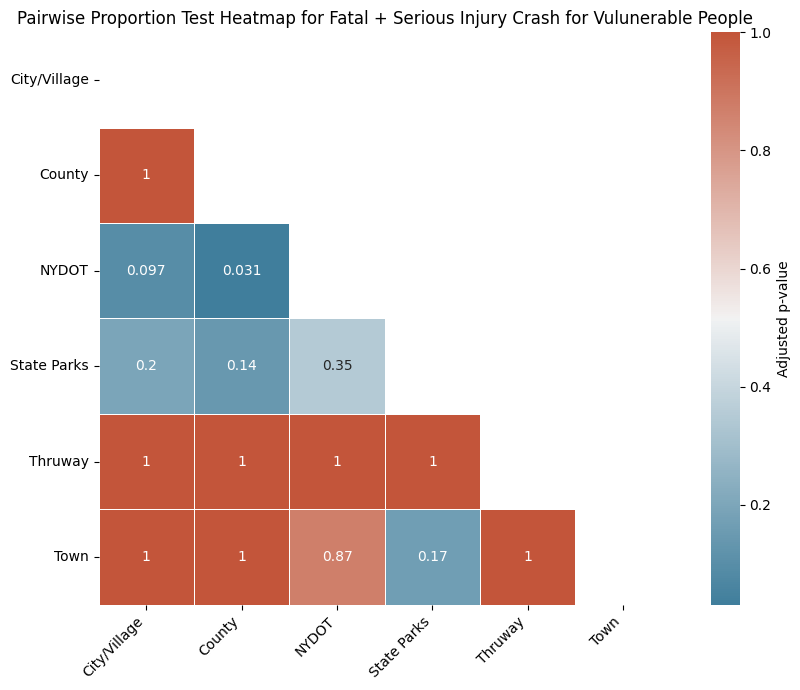

In [52]:

ppt["Group1"] = ppt["Group1"].replace({"State": "NYDOT"})
ppt["Group2"] = ppt["Group2"].replace({"State": "NYDOT"})
groups = sorted(set(ppt["Group1"]).union(set(ppt["Group2"])))

heatmap_data = pd.DataFrame(
    np.ones((len(groups), len(groups))),
    index = groups,
    columns = groups
)

for _, row in ppt.iterrows():
    g1 = row["Group1"]
    g2 = row["Group2"]
    p_adj = row["p_adj"]
    
    heatmap_data.loc[g1, g2] = p_adj
    heatmap_data.loc[g2, g1] = p_adj   

mask = np.triu(np.ones_like(heatmap_data, dtype = bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    mask = mask,
    annot = True,
    fmt =".2g",
    cmap = sns.diverging_palette(230, 20, as_cmap = True),   
    linewidths = 0.5,
    square = True,
    cbar_kws = {"label": "Adjusted p-value"}
)

plt.title("Pairwise Proportion Test Heatmap for Fatal + Serious Injury Crash for Vulunerable People")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

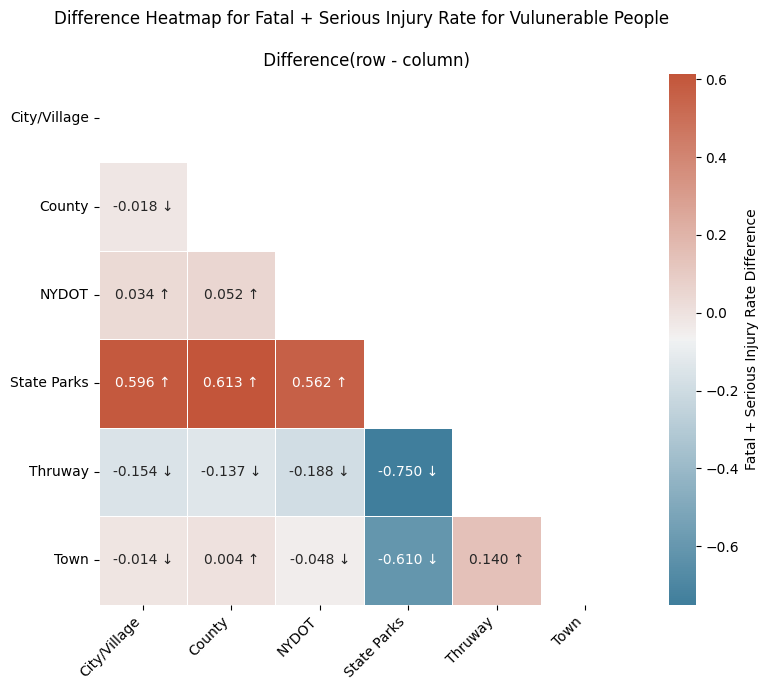

In [68]:
groups = sorted(set(ppt["Group1"]).union(set(ppt["Group2"])))

heatmap_data = pd.DataFrame(
    np.ones((len(groups), len(groups))),
    index = groups,
    columns = groups
)

for _, row in ppt.iterrows():
    g1 = row["Group1"]
    g2 = row["Group2"]
    p1 = row["p1"]
    p2 = row["p2"]
    Difference = row["p1"] - row["p2"]
    
    heatmap_data.loc[g1, g2] = Difference  
    heatmap_data.loc[g2, g1] = -Difference     

annot = heatmap_data.copy().astype(object)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        if val > 0:
            annot.iloc[i, j] = f"{val:.3f} ↑"
        elif val < 0:
            annot.iloc[i, j] = f"{val:.3f} ↓"
        else:
            annot.iloc[i, j] = "0"

mask = np.triu(np.ones_like(heatmap_data, dtype = bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    mask = mask,
    annot = annot,
    fmt ="",
    cmap = sns.diverging_palette(230, 20, as_cmap = True),   
    linewidths = 0.5,
    square = True,
    cbar_kws={"label":  "Fatal + Serious Injury Rate Difference"}
)

plt.title("Difference Heatmap for Fatal + Serious Injury Rate for Vulunerable People \n\n Difference(row - column)")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

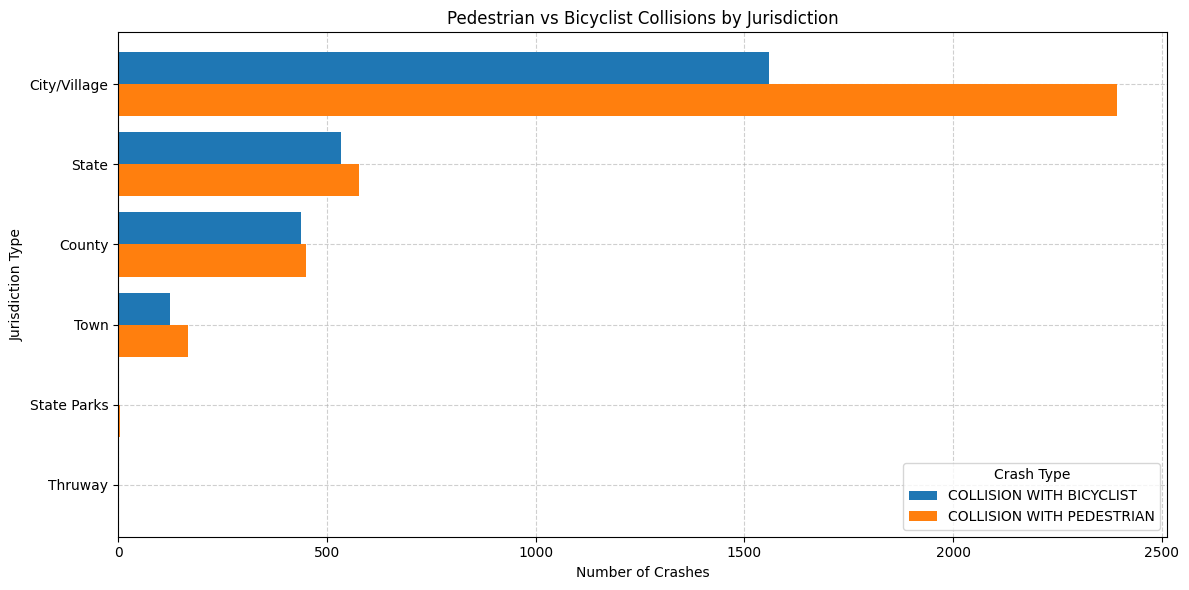

In [54]:
df_selected = df[
    (df["OWNING_JURISDICTION"] != "Unknown") &
    (df["OWNING_JURISDICTION"] != "Other") & 
    (df["CrashType"].isin(target_types))
].copy()

stat = (
    df_selected.groupby(["OWNING_JURISDICTION", "CrashType"])
    .size()
    .reset_index(name = "Count")
)

stat_wide = stat.pivot(index = "OWNING_JURISDICTION", columns = "CrashType", values = "Count").fillna(0)

stat_wide["Total"] = stat_wide.get("COLLISION WITH PEDESTRIAN", 0) + stat_wide.get("COLLISION WITH BICYCLIST", 0)
stat_wide = stat_wide.sort_values("Total", ascending = False)
stat_wide = stat_wide.drop(columns = "Total")

ax = stat_wide.plot(kind = "barh",width = 0.8, figsize = (12, 6))

plt.xlabel("Number of Crashes")
plt.ylabel("Jurisdiction Type")
plt.title("Pedestrian vs Bicyclist Collisions by Jurisdiction")
plt.legend(
    title = "Crash Type",
    loc = "lower right"
)

ax.grid(True, linestyle = "--", alpha = 0.6)
ax.set_axisbelow(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [55]:
crosstb = pd.crosstab(
    df_selected["OWNING_JURISDICTION"],
    df_selected["CrashType"]
)

In [56]:
crosstb_jp = pd.crosstab(
    df_selected["OWNING_JURISDICTION"],
    df_selected["CrashType"],
    normalize = "columns"
)

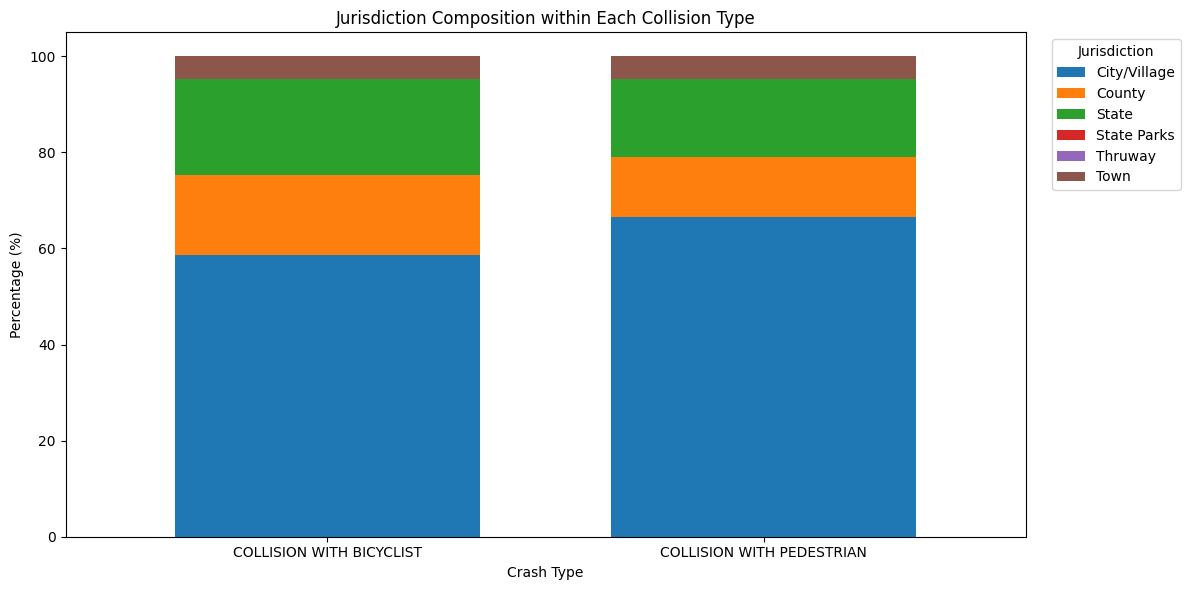

In [57]:


df_plot = (crosstb_jp.T * 100)

ax = df_plot.plot(
    kind = "bar",
    stacked = True,
    figsize = (12, 6),
    width = 0.7
)

plt.xlabel("Crash Type")
plt.ylabel("Percentage (%)")
plt.title("Jurisdiction Composition within Each Collision Type")
plt.legend(title = "Jurisdiction", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

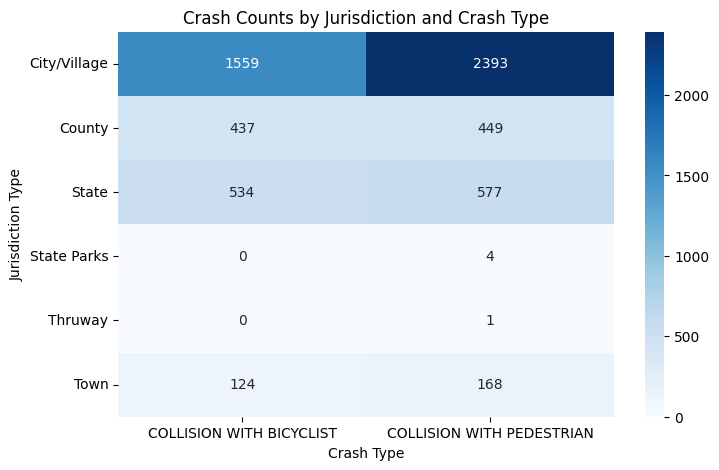

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))
sns.heatmap(crosstb, annot = True, fmt = "d", cmap = "Blues")
plt.title("Crash Counts by Jurisdiction and Crash Type")
plt.xlabel("Crash Type")
plt.ylabel("Jurisdiction Type")
plt.show()

In [59]:
# Test of Independence
# H0 = OWNING_JURISDICTION and CrashType independent
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(crosstb)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# The chi-square test of independence showed a significant association between OWNING_JURISDICTION and CrashType, X2(6) = 50.45,
# p < 0.001. We therefore reject the null hypothesis of independence and conclude that crash type distribution  differs significantly
# across jurisdiction types.

Chi-square: 49.713941862369026
p-value: 1.5857164452195476e-09
Degrees of freedom: 5


In [60]:
n = crosstb.to_numpy().sum()
r, c = crosstb.shape

cv = np.sqrt(chi2 / (n * min(r - 1, c - 1)))
print("Cramér's V:", cv)

# Cramér’s V indicates a small effect size, suggesting that the association between jurisdiction 
# type and crash type is statistically significant but not very strong in practical terms.

Cramér's V: 0.08921504730573837


In [61]:
stat_fsi = (
    df_selected.groupby(["OWNING_JURISDICTION", "CrashType"])
    .agg(
        TotalCrashes = ("CrashType", "count"),
        TotalFSI = ("fsi_crash", "sum")
    )
    .reset_index()
)

stat_fsi["FSIRate"] = stat_fsi["TotalFSI"] / stat_fsi["TotalCrashes"]
fsi_rate = stat_fsi.pivot(index = "OWNING_JURISDICTION", columns = "CrashType", values = "FSIRate").fillna(0)

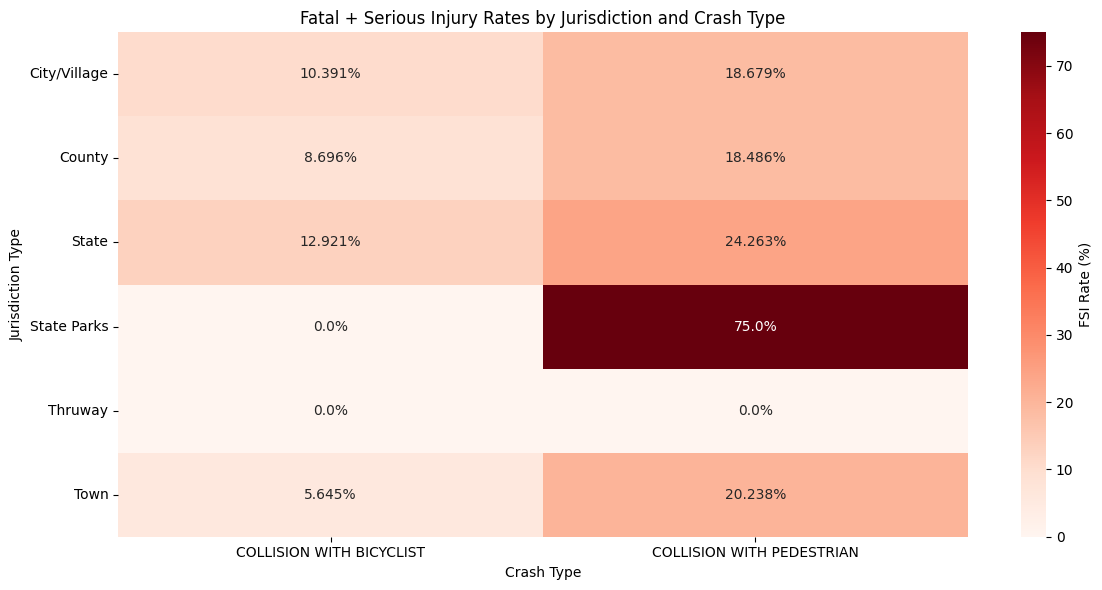

In [62]:
plt.figure(figsize = (12, 6))
labels_p = (fsi_rate * 100).round(3).astype(str) + "%"
sns.heatmap(fsi_rate * 100, annot =  labels_p, fmt = "", cmap = "Reds", cbar_kws = {"label": "FSI Rate (%)"})
plt.title("Fatal + Serious Injury Rates by Jurisdiction and Crash Type")
plt.xlabel("Crash Type")
plt.ylabel("Jurisdiction Type")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [63]:
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

In [64]:
stat_fsi_wide = stat_fsi.pivot(index = "OWNING_JURISDICTION", columns = "CrashType", values = ["TotalCrashes", "TotalFSI"]).fillna(0)
stat_fsi_wide.columns = [
    f"{x}_{y}" 
    for x, y in stat_fsi_wide.columns
]
stat_fsi_wide = stat_fsi_wide.reset_index()
stat_fsi_wide

,OWNING_JURISDICTION,TotalCrashes_COLLISION WITH BICYCLIST,TotalCrashes_COLLISION WITH PEDESTRIAN,TotalFSI_COLLISION WITH BICYCLIST,TotalFSI_COLLISION WITH PEDESTRIAN
0,City/Village,1559.0,2393.0,162.0,447.0
1,County,437.0,449.0,38.0,83.0
2,State,534.0,577.0,69.0,140.0
3,State Parks,0.0,4.0,0.0,3.0
4,Thruway,0.0,1.0,0.0,0.0
5,Town,124.0,168.0,7.0,34.0


In [65]:
# Test of equal FSI rates between bicyclist and pedestrian crashes
# H0 = bike FSI = ped FSI

bike_fsi = stat_fsi_wide["TotalFSI_COLLISION WITH BICYCLIST"].sum()
ped_fsi  = stat_fsi_wide["TotalFSI_COLLISION WITH PEDESTRIAN"].sum()

bike_total = stat_fsi_wide["TotalCrashes_COLLISION WITH BICYCLIST"].sum()
ped_total  = stat_fsi_wide["TotalCrashes_COLLISION WITH PEDESTRIAN"].sum()

count = [bike_fsi, ped_fsi]
numobs  = [bike_total, ped_total]

stat, p = proportions_ztest(count, numobs)

print("z-statistic:", stat)
print("p-value:", p)
# one sample proportion z test showed that the overall proportions of bicyclist and pedestrian crashes were not equal, 
# where z = -9.95,p < 0.001. Therefore, the null hypothesis is rejected.

z-statistic: -9.959219934199114
p-value: 2.2985912670949372e-23


In [66]:
# Test of equal FSI rates between bicyclist and pedestrian crashes by jurisdiction
# H0 = bike FSI = ped FSI by jursdiction 
results = []

for _, r in stat_fsi_wide.iterrows():
    j = r["OWNING_JURISDICTION"]
    
    bike_total = r["TotalCrashes_COLLISION WITH BICYCLIST"]
    bike_fsi   = r["TotalFSI_COLLISION WITH BICYCLIST"]
    bike_non   = bike_total - bike_fsi
    
    ped_total  = r["TotalCrashes_COLLISION WITH PEDESTRIAN"]
    ped_fsi    = r["TotalFSI_COLLISION WITH PEDESTRIAN"]
    ped_non    = ped_total - ped_fsi

    if bike_total == 0 or ped_total == 0:
        results.append({"Test": "Not applicable", "Jurisdiction": j, "p_value": np.nan})
        continue

    test_table = np.array([[bike_fsi, bike_non],[ped_fsi,  ped_non]])

    if (test_table < 10).any():
        test_name = "Fisher exact"
        oddsratio, p = fisher_exact(test_table)
    else:
        test_name = "Two-proportion z-test"
        fsi_count = [bike_fsi, ped_fsi]
        numobs  = [bike_total, ped_total]
        stat, p = proportions_ztest(fsi_count, numobs)

    results.append({"Test": test_name, "Jurisdiction": j, "p_value": p})

df_testresult = pd.DataFrame(results)
mask = df_testresult["p_value"].notna()
df_testresult.loc[mask, "p_adj_bonf"] = multipletests(df_testresult.loc[mask, "p_value"], method = "bonferroni")[1]
df_testresult.loc[mask, "significance (95% interval)"] = df_testresult.loc[mask, "p_adj_bonf"] < 0.05

print(df_testresult)

# After comparing FSI number between bicyclist and pedestrian crashes within each jurisdiction and applying Bonferroni correction, significant differences 
# were found in City/Village, County, State, and Town. Tests were not applicable for State Parks, and Thruway due to insufficient counts. 
# n jurisdictions where testing was aviable, FSI risk differs significantly by crash type.

                    Test  Jurisdiction       p_value    p_adj_bonf  \
0  Two-proportion z-test  City/Village  1.748422e-12  6.993688e-12   
1  Two-proportion z-test        County  2.209235e-05  8.836940e-05   
2  Two-proportion z-test         State  1.343766e-06  5.375064e-06   
3         Not applicable   State Parks           NaN           NaN   
4         Not applicable       Thruway           NaN           NaN   
5           Fisher exact          Town  2.988941e-04  1.195576e-03   

  significance (95% interval)  
0                        True  
1                        True  
2                        True  
3                         NaN  
4                         NaN  
5                        True  


In [67]:
# removed since logit won't converge
df_logit = df_selected[~df_selected["OWNING_JURISDICTION"].isin(["Interstate", "State Parks", "Thruway"])].copy()

model = smf.logit('fsi_crash ~ C(CrashType) + C(OWNING_JURISDICTION)', data = df_logit).fit()

print(model.summary())

oddratio_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "p_value": model.pvalues
})
print(oddratio_table)

# After removing sparse jurisdictions that prevented convergence, the logistic regression model converged successfully.
# The results show that, after controlling for OWNING_JURISDICTION, CrashType remains a significant predictor of fsi_crash. 
# Compared with COLLISION WITH BICYCLIST, COLLISION WITH PEDESTRIAN is associated with significantly higher odds of FSI, 
# with an odds ratio of about 2.13. In addition, State jurisdiction has significantly higher FSI odds than City/Village, while County and Town do 
# not differ significantly from City/Village.

Optimization terminated successfully.
         Current function value: 0.425422
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              fsi_crash   No. Observations:                 6241
Model:                          Logit   Df Residuals:                     6236
Method:                           MLE   Df Model:                            4
Date:                Sat, 02 May 2026   Pseudo R-squ.:                 0.02136
Time:                        23:19:26   Log-Likelihood:                -2655.1
converged:                       True   LL-Null:                       -2713.0
Covariance Type:            nonrobust   LLR p-value:                 4.055e-24
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -